In [1]:
# Cell 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
sns.set_style('whitegrid')

In [7]:
df = pd.read_csv('../data/flipkart_laptops.csv')
print(df.shape)
print(df.columns.tolist())
df.head()

(414, 8)
['Name', 'Brand', 'Selling Price', 'MRP', 'Discount', 'Ratings', 'No_of_ratings', 'Details']


,Name,Brand,Selling Price,MRP,Discount,Ratings,No_of_ratings,Details
0,Lenovo IdeaPad 3 Core i3 11th Gen - (8 GB/256 ...,Lenovo,36990,60890,39% off,4.2,670 Ratings & 54 Reviews,['Intel Core i3 Processor (11th Gen)' '8 GB DD...
1,Lenovo IdeaPad 3 Core i3 11th Gen - (8 GB/512 ...,Lenovo,37990,59390,36% off,4.2,3803 Ratings & 362 Reviews,['Intel Core i3 Processor (11th Gen)' '8 GB DD...
2,ASUS VivoBook 15 (2022) Core i3 10th Gen - (8 ...,ASUS,32990,45990,28% off,4.3,8727 Ratings & 876 Reviews,['Intel Core i3 Processor (10th Gen)' '8 GB DD...
3,realme Book (Slim) Core i3 11th Gen - (8 GB/25...,realme,46990,54999,14% off,4.4,11894 Ratings & 1773 Reviews,['Stylish & Portable Thin and Light Laptop' '1...
4,DELL Inspiron Core i3 11th Gen - (8 GB/1 TB HD...,DELL,38990,61202,36% off,4.3,65 Ratings & 6 Reviews,['Processor: Intel i3-1115G4 (Base- 1.70 GHz &...


In [9]:
df['Discount'] = df['Discount'].str.replace('% off', '').astype(int)

In [10]:
df['Num_Ratings'] = df['No_of_ratings'].str.split(' ').str[0].astype(int)

In [11]:
df.dropna(subset=['Ratings', 'Selling Price'], inplace=True)
print("Clean shape:", df.shape)
print(df[['Brand','Selling Price','MRP','Discount','Ratings','Num_Ratings']].head())

Clean shape: (414, 9)
    Brand  Selling Price    MRP  Discount  Ratings  Num_Ratings
0  Lenovo          36990  60890        39      4.2          670
1  Lenovo          37990  59390        36      4.2         3803
2    ASUS          32990  45990        28      4.3         8727
3  realme          46990  54999        14      4.4        11894
4    DELL          38990  61202        36      4.3           65


In [12]:
df['Price_Category'] = pd.cut(
    df['Selling Price'],
    bins=[0, 40000, 70000, 300000],
    labels=['Budget', 'Mid-Range', 'Premium']
)
print(df['Price_Category'].value_counts())

Price_Category
Mid-Range    169
Premium      143
Budget       100
Name: count, dtype: int64


In [13]:
print("Avg Selling Price: ₹", df['Selling Price'].mean().round())
print("Avg Rating:", df['Ratings'].mean().round(2))
print("Avg Discount:", df['Discount'].mean().round(1), "%")
corr = df['Selling Price'].corr(df['Ratings'])
print(f"Price vs Rating correlation: {corr:.2f}")

Avg Selling Price: ₹ 69708.0
Avg Rating: 4.28
Avg Discount: 22.8 %
Price vs Rating correlation: 0.30


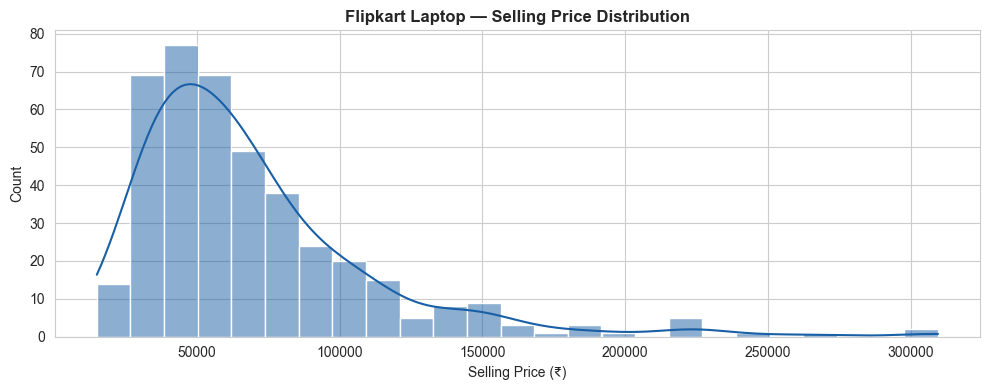

In [18]:
# Cell 8 — Chart 1: Price Distribution
plt.figure(figsize=(10,4))
sns.histplot(df['Selling Price'], bins=25, kde=True, color='#185FA5')
plt.title('Flipkart Laptop — Selling Price Distribution', fontweight='bold')
plt.xlabel('Selling Price (₹)'); plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../charts/01_price_distribution.png', dpi=300)
plt.show()

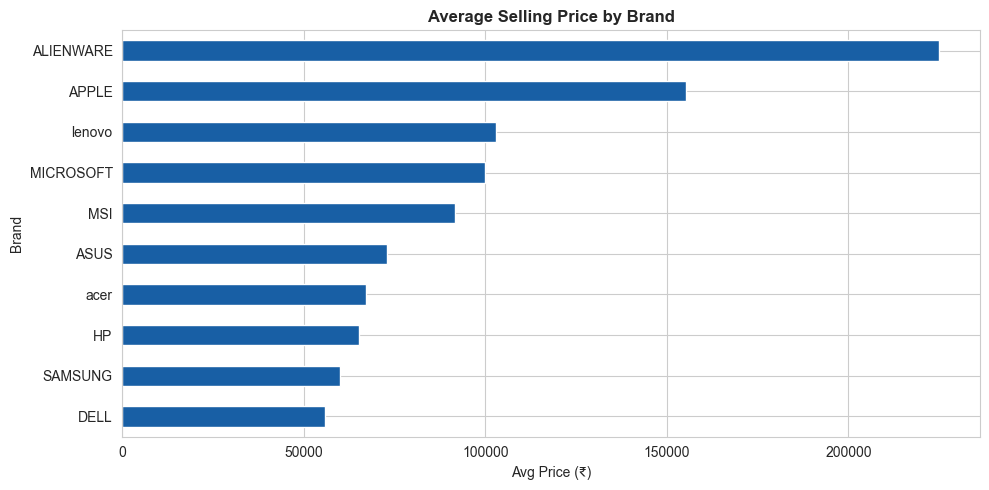

In [19]:
# Cell 9 — Chart 2: Brand vs Avg Price
brand_avg = df.groupby('Brand')['Selling Price'].mean().sort_values().tail(10)
plt.figure(figsize=(10,5))
brand_avg.plot(kind='barh', color='#185FA5')
plt.title('Average Selling Price by Brand', fontweight='bold')
plt.xlabel('Avg Price (₹)')
plt.tight_layout()
plt.savefig('../charts/02_brand_price.png', dpi=150)
plt.show()

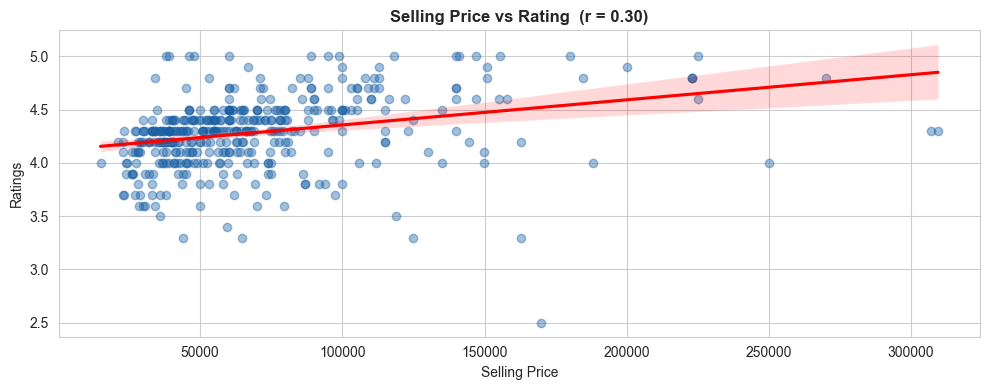

In [21]:
#Chart 3: Price vs Rating scatter + trend line
plt.figure(figsize=(10,4))
sns.regplot(data=df, x='Selling Price', y='Ratings',
            scatter_kws={'alpha':0.4, 'color':'#185FA5'},
            line_kws={'color':'red'})
plt.title(f'Selling Price vs Rating  (r = {corr:.2f})', fontweight='bold')
plt.tight_layout()
plt.savefig('../charts/03_price_vs_rating.png', dpi=150)
plt.show()

C:\Users\thelu\AppData\Local\Temp\ipykernel_19392\2774162398.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Price_Category', y='Ratings',


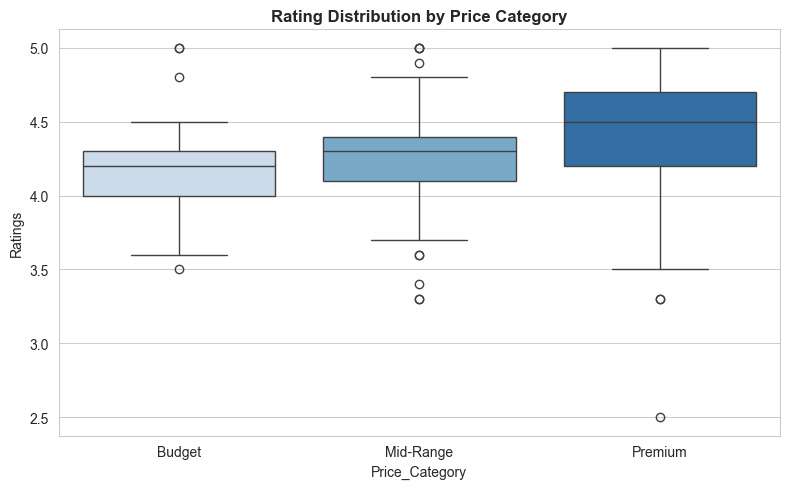

In [22]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Price_Category', y='Ratings',
            order=['Budget','Mid-Range','Premium'], palette='Blues')
plt.title('Rating Distribution by Price Category', fontweight='bold')
plt.tight_layout()
plt.savefig('../charts/04_boxplot.png', dpi=150)
plt.show()

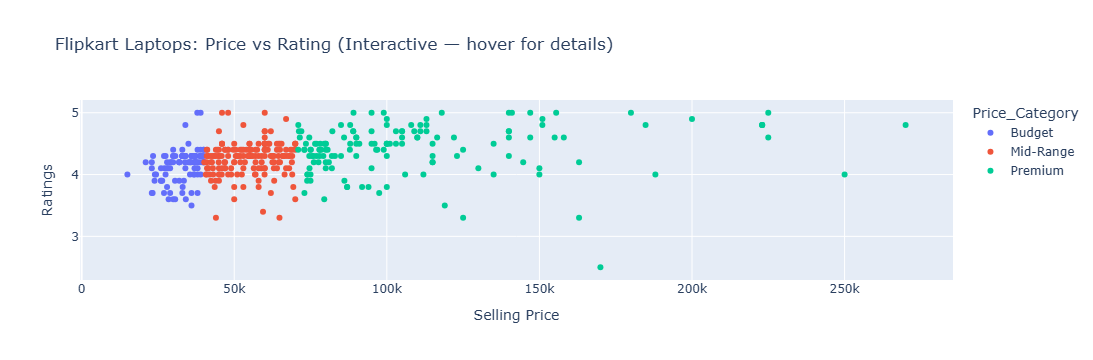

In [24]:
fig = px.scatter(
    df, x='Selling Price', y='Ratings',
    color='Price_Category',
    hover_name='Name',
    hover_data={'Brand': True, 'Discount': True, 'Num_Ratings': True},
    title='Flipkart Laptops: Price vs Rating (Interactive — hover for details)'
)
fig.show()
fig.write_html('../charts/interactive.html')

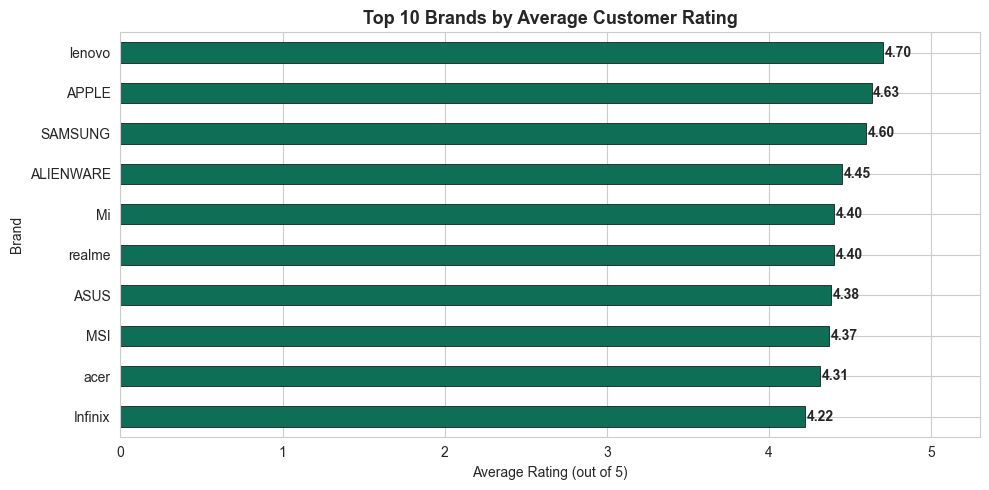

In [26]:
plt.figure(figsize=(10, 5))
brand_rating.sort_values().plot(kind='barh', color='#0F6E56', edgecolor='black', linewidth=0.5)

# Add value labels at end of each bar
for i, val in enumerate(brand_rating.sort_values()):
    plt.text(val + 0.01, i, f'{val:.2f}', va='center', fontsize=10, fontweight='bold')

plt.title('Top 10 Brands by Average Customer Rating', fontweight='bold', fontsize=13)
plt.xlabel('Average Rating (out of 5)')
plt.ylabel('Brand')
plt.xlim(0, 5.3)  # give space for labels
plt.tight_layout()
plt.savefig('../charts/05_brand_rating.png', dpi=150)
plt.show()